# Homework: EVD (EigenValue Decomposition)

We implement the Jacobi eigenvalue algorithm for real symmetric matrices.

The decomposition is

$$
A = VDV^T,
$$

where $D$ is diagonal and contains the eigenvalues, and $V$ contains the corresponding eigenvectors as columns.

We test:

- $V^T A V = D$
- $V D V^T = A$
- $V^T V = I$
- $V V^T = I$

## Task A

In [1]:
from pathlib import Path

Path("evd.hpp").write_text(r'''
#pragma once
#include "matrix.hpp"
#include <cmath>
#include <stdexcept>
#include <algorithm>

namespace pp {

struct EVD {
    vector w;
    matrix V;
    int sweeps = 0;
    int rotations = 0;

    static void timesJ(matrix& A, int p, int q, double theta) {
        double c = std::cos(theta);
        double s = std::sin(theta);

        for (int i = 0; i < A.size1(); ++i) {
            double aip = A(i, p);
            double aiq = A(i, q);

            A(i, p) = c * aip - s * aiq;
            A(i, q) = s * aip + c * aiq;
        }
    }

    static void Jtimes(matrix& A, int p, int q, double theta) {
        double c = std::cos(theta);
        double s = std::sin(theta);

        for (int j = 0; j < A.size2(); ++j) {
            double apj = A(p, j);
            double aqj = A(q, j);

            A(p, j) = c * apj + s * aqj;
            A(q, j) = -s * apj + c * aqj;
        }
    }

    explicit EVD(matrix A, double tol = 1e-12, int max_sweeps = 100) 
        : w(A.size1()), V(matrix::identity(A.size1())) 
    {
        int n = A.size1();

        if (A.size1() != A.size2()) {
            throw std::runtime_error("EVD needs a square matrix");
        }

        bool changed;

        do {
            changed = false;
            ++sweeps;

            for (int p = 0; p < n - 1; ++p) {
                for (int q = p + 1; q < n; ++q) {
                    double apq = A(p, q);

                    if (std::abs(apq) > tol) {
                        double app = A(p, p);
                        double aqq = A(q, q);

                        double theta = 0.5 * std::atan2(2.0 * apq, aqq - app);

                        changed = true;
                        ++rotations;

                        timesJ(A, p, q, theta);      // A <- A J
                        Jtimes(A, p, q, -theta);    // A <- J^T A
                        timesJ(V, p, q, theta);      // V <- V J
                    }
                }
            }

            if (sweeps > max_sweeps) {
                throw std::runtime_error("EVD did not converge");
            }

        } while (changed);

        for (int i = 0; i < n; ++i) {
            w[i] = A(i, i);
        }

        sort_eigenpairs();
    }

private:
    void sort_eigenpairs() {
        int n = w.size();

        for (int i = 0; i < n - 1; ++i) {
            int k = i;

            for (int j = i + 1; j < n; ++j) {
                if (w[j] < w[k]) {
                    k = j;
                }
            }

            if (k != i) {
                std::swap(w[i], w[k]);

                for (int r = 0; r < V.size1(); ++r) {
                    std::swap(V(r, i), V(r, k));
                }
            }
        }
    }
};

inline matrix diag(const vector& w) {
    int n = w.size();
    matrix D(n, n);

    for (int i = 0; i < n; ++i) {
        D(i, i) = w[i];
    }

    return D;
}

}
''')

print("Wrote evd.hpp")

Wrote evd.hpp


In [2]:
from pathlib import Path

Path("evd_test.cpp").write_text(r'''
#include "evd.hpp"
#include <iostream>
#include <random>
#include <iomanip>

pp::matrix random_symmetric_matrix(int n, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::matrix A(n, n);

    for (int i = 0; i < n; ++i) {
        for (int j = i; j < n; ++j) {
            double x = dist(gen);
            A(i, j) = x;
            A(j, i) = x;
        }
    }

    return A;
}

void print_check(const std::string& name, bool ok, double err) {
    std::cout << std::left << std::setw(24) << name
              << " : " << (ok ? "OK" : "FAILED")
              << "    error = " << err << "\n";
}

int main() {
    std::mt19937 gen(2);

    int n = 6;
    pp::matrix A = random_symmetric_matrix(n, gen);

    pp::EVD evd(A);

    pp::matrix V = evd.V;
    pp::matrix D = pp::diag(evd.w);
    pp::matrix I = pp::matrix::identity(n);

    pp::matrix VTAV = V.T() * A * V;
    pp::matrix VDVT = V * D * V.T();
    pp::matrix VTV  = V.T() * V;
    pp::matrix VVT  = V * V.T();

    std::cout << "Task A: Jacobi diagonalization with cyclic sweeps\n";
    std::cout << "------------------------------------------------\n";

    print_check("V^T A V = D", pp::approx(VTAV, D, 1e-8), pp::max_abs_diff(VTAV, D));
    print_check("V D V^T = A", pp::approx(VDVT, A, 1e-8), pp::max_abs_diff(VDVT, A));
    print_check("V^T V = I", pp::approx(VTV, I, 1e-8), pp::max_abs_diff(VTV, I));
    print_check("V V^T = I", pp::approx(VVT, I, 1e-8), pp::max_abs_diff(VVT, I));

    std::cout << "\nEigenvalues:\n";
    for (int i = 0; i < evd.w.size(); ++i) {
        std::cout << "w[" << i << "] = " << evd.w[i] << "\n";
    }

    std::cout << "\nSweeps    = " << evd.sweeps << "\n";
    std::cout << "Rotations = " << evd.rotations << "\n";

    return 0;
}
''')

print("Wrote evd_test.cpp")

Wrote evd_test.cpp


In [3]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "evd_test.cpp",
    "-o",
    "evd_test"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(["./evd_test"], text=True, capture_output=True)
    print("Program output:")
    print(r.stdout)
    print(r.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task A: Jacobi diagonalization with cyclic sweeps
------------------------------------------------
V^T A V = D              : OK    error = 2.12164e-13
V D V^T = A              : OK    error = 9.9476e-14
V^T V = I                : OK    error = 8.88178e-16
V V^T = I                : OK    error = 6.66134e-16

Eigenvalues:
w[0] = -4.62415
w[1] = -2.80856
w[2] = -0.910061
w[3] = 1.41544
w[4] = 1.70149
w[5] = 2.42372

Sweeps    = 6
Rotations = 59




## Task B
Hydrogen atom on a grid

In [4]:
from pathlib import Path

Path("hydrogen.cpp").write_text(r'''
#include "evd.hpp"
#include <iostream>
#include <iomanip>
#include <cstdlib>
#include <cmath>

pp::matrix hydrogen_hamiltonian(double rmax, double dr) {
    int npoints = static_cast<int>(rmax / dr) - 1;

    pp::vector r(npoints);
    for (int i = 0; i < npoints; ++i) {
        r[i] = dr * (i + 1);
    }

    pp::matrix H(npoints, npoints);

    // Kinetic energy matrix:
    // K = -1/2 * d^2/dr^2
    for (int i = 0; i < npoints - 1; ++i) {
        H(i, i)     = -2.0 * (-0.5 / (dr * dr));
        H(i, i + 1) =  1.0 * (-0.5 / (dr * dr));
        H(i + 1, i) =  1.0 * (-0.5 / (dr * dr));
    }

    H(npoints - 1, npoints - 1) = -2.0 * (-0.5 / (dr * dr));

    // Potential energy matrix:
    // W_ii = -1/r_i
    for (int i = 0; i < npoints; ++i) {
        H(i, i) += -1.0 / r[i];
    }

    return H;
}

double exact_energy(int n) {
    return -0.5 / (n * n);
}

int main(int argc, char** argv) {
    double rmax = 10.0;
    double dr = 0.3;

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-rmax" && i + 1 < argc) {
            rmax = std::atof(argv[i + 1]);
            ++i;
        }

        if (arg == "-dr" && i + 1 < argc) {
            dr = std::atof(argv[i + 1]);
            ++i;
        }
    }

    int npoints = static_cast<int>(rmax / dr) - 1;

    pp::matrix H = hydrogen_hamiltonian(rmax, dr);
    pp::EVD evd(H, 1e-12, 300);

    std::cout << "Task B: Hydrogen atom, s-wave radial Schrodinger equation\n";
    std::cout << "---------------------------------------------------------\n";
    std::cout << "rmax    = " << rmax << "\n";
    std::cout << "dr      = " << dr << "\n";
    std::cout << "npoints = " << npoints << "\n\n";

    std::cout << std::left
              << std::setw(10) << "state"
              << std::setw(18) << "numeric"
              << std::setw(18) << "exact"
              << std::setw(18) << "error"
              << "\n";

    for (int k = 0; k < 4 && k < evd.w.size(); ++k) {
        double numeric = evd.w[k];
        double exact = exact_energy(k + 1);

        std::cout << std::left
                  << std::setw(10) << k
                  << std::setw(18) << numeric
                  << std::setw(18) << exact
                  << std::setw(18) << std::abs(numeric - exact)
                  << "\n";
    }

    std::cout << "\nSweeps    = " << evd.sweeps << "\n";
    std::cout << "Rotations = " << evd.rotations << "\n";

    return 0;
}
''')

print("Wrote hydrogen.cpp")

Wrote hydrogen.cpp


In [5]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "hydrogen.cpp",
    "-o",
    "hydrogen"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(
        ["./hydrogen", "-rmax", "10", "-dr", "0.3"],
        text=True,
        capture_output=True
    )
    print("Program output:")
    print(r.stdout)
    print(r.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Task B: Hydrogen atom, s-wave radial Schrodinger equation
---------------------------------------------------------
rmax    = 10
dr      = 0.3
npoints = 32

state     numeric           exact             error             
0         -0.489228         -0.5              0.0107717         
1         -0.11112          -0.125            0.0138798         
2         0.0962839         -0.0555556        0.151839          
3         0.411759          -0.03125          0.443009          

Sweeps    = 9
Rotations = 2909




Convergence with respect to Δr:

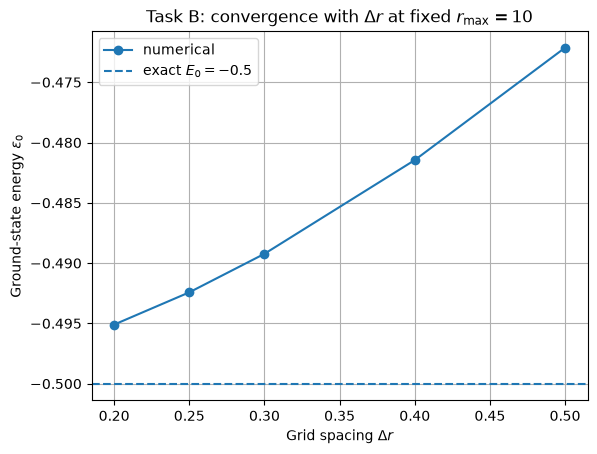

dr =  0.500, E0 = -0.47213500, error = 2.786e-02
dr =  0.400, E0 = -0.48145500, error = 1.854e-02
dr =  0.300, E0 = -0.48922800, error = 1.077e-02
dr =  0.250, E0 = -0.49242200, error = 7.578e-03
dr =  0.200, E0 = -0.49509700, error = 4.903e-03


In [6]:
import subprocess
import numpy as np
import matplotlib.pyplot as plt

def ground_energy(rmax, dr):
    r = subprocess.run(
        ["./hydrogen", "-rmax", str(rmax), "-dr", str(dr)],
        text=True,
        capture_output=True
    )
    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError("hydrogen failed")

    for line in r.stdout.splitlines():
        parts = line.split()
        if len(parts) >= 4 and parts[0] == "0":
            return float(parts[1])

    raise RuntimeError("Could not parse ground-state energy")

rmax = 10.0
dr_values = np.array([0.5, 0.4, 0.3, 0.25, 0.2])
E0_values = np.array([ground_energy(rmax, dr) for dr in dr_values])

plt.figure()
plt.plot(dr_values, E0_values, "o-", label="numerical")
plt.axhline(-0.5, linestyle="--", label="exact $E_0=-0.5$")
plt.xlabel(r"Grid spacing $\Delta r$")
plt.ylabel(r"Ground-state energy $\epsilon_0$")
plt.title(r"Task B: convergence with $\Delta r$ at fixed $r_{\max}=10$")
plt.grid(True)
plt.legend()
plt.show()

for dr, E0 in zip(dr_values, E0_values):
    print(f"dr = {dr:6.3f}, E0 = {E0: .8f}, error = {abs(E0 + 0.5):.3e}")

Convergence with respect to rmax:

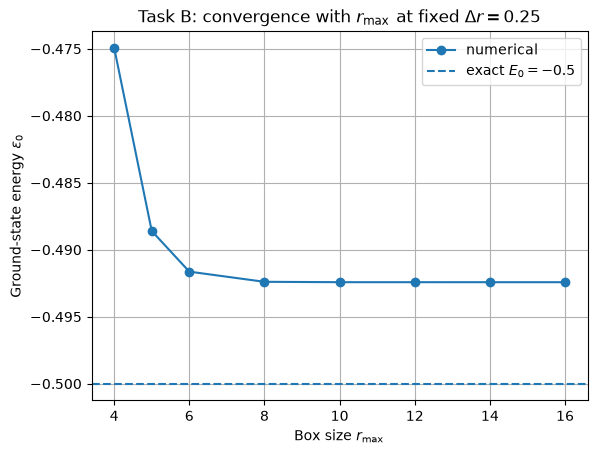

rmax =   4.00, E0 = -0.47491700, error = 2.508e-02
rmax =   5.00, E0 = -0.48860000, error = 1.140e-02
rmax =   6.00, E0 = -0.49163500, error = 8.365e-03
rmax =   8.00, E0 = -0.49239400, error = 7.606e-03
rmax =  10.00, E0 = -0.49242200, error = 7.578e-03
rmax =  12.00, E0 = -0.49242200, error = 7.578e-03
rmax =  14.00, E0 = -0.49242300, error = 7.577e-03
rmax =  16.00, E0 = -0.49242300, error = 7.577e-03


In [7]:
dr = 0.25
rmax_values = np.array([4, 5, 6, 8, 10, 12, 14, 16], dtype=float)
E0_values = np.array([ground_energy(rmax, dr) for rmax in rmax_values])

plt.figure()
plt.plot(rmax_values, E0_values, "o-", label="numerical")
plt.axhline(-0.5, linestyle="--", label="exact $E_0=-0.5$")
plt.xlabel(r"Box size $r_{\max}$")
plt.ylabel(r"Ground-state energy $\epsilon_0$")
plt.title(r"Task B: convergence with $r_{\max}$ at fixed $\Delta r=0.25$")
plt.grid(True)
plt.legend()
plt.show()

for rmax, E0 in zip(rmax_values, E0_values):
    print(f"rmax = {rmax:6.2f}, E0 = {E0: .8f}, error = {abs(E0 + 0.5):.3e}")

Wavefunctions:

In [8]:
from pathlib import Path

Path("hydrogen_wavefunctions.cpp").write_text(r'''
#include "evd.hpp"
#include <iostream>
#include <iomanip>
#include <cstdlib>
#include <cmath>
#include <vector>
#include <string>

pp::matrix hydrogen_hamiltonian(double rmax, double dr) {
    int npoints = static_cast<int>(rmax / dr) - 1;

    std::vector<double> r(npoints);
    for (int i = 0; i < npoints; ++i) {
        r[i] = dr * (i + 1);
    }

    pp::matrix H(npoints, npoints);

    for (int i = 0; i < npoints - 1; ++i) {
        H(i, i)     = -2.0 * (-0.5 / (dr * dr));
        H(i, i + 1) =  1.0 * (-0.5 / (dr * dr));
        H(i + 1, i) =  1.0 * (-0.5 / (dr * dr));
    }

    H(npoints - 1, npoints - 1) = -2.0 * (-0.5 / (dr * dr));

    for (int i = 0; i < npoints; ++i) {
        H(i, i) += -1.0 / r[i];
    }

    return H;
}

double exact_energy(int n) {
    return -0.5 / (n * n);
}

double exact_f(int k, double r) {
    // k = 0,1,2 correspond to n = 1,2,3 s-states.
    if (k == 0) {
        return 2.0 * r * std::exp(-r);
    }

    if (k == 1) {
        return r * (2.0 - r) * std::exp(-r / 2.0) / (2.0 * std::sqrt(2.0));
    }

    if (k == 2) {
        return r * (2.0 / (81.0 * std::sqrt(3.0)))
                 * (27.0 - 18.0 * r + 2.0 * r * r)
                 * std::exp(-r / 3.0);
    }

    return 0.0;
}

int main(int argc, char** argv) {
    double rmax = 20.0;
    double dr = 0.2;

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-rmax" && i + 1 < argc) {
            rmax = std::atof(argv[i + 1]);
            ++i;
        }

        if (arg == "-dr" && i + 1 < argc) {
            dr = std::atof(argv[i + 1]);
            ++i;
        }
    }

    int npoints = static_cast<int>(rmax / dr) - 1;

    std::vector<double> r(npoints);
    for (int i = 0; i < npoints; ++i) {
        r[i] = dr * (i + 1);
    }

    pp::matrix H = hydrogen_hamiltonian(rmax, dr);
    pp::EVD evd(H, 1e-12, 400);

    int states = 3;
    std::vector<double> signs(states, 1.0);

    for (int k = 0; k < states; ++k) {
        double dot = 0.0;

        for (int i = 0; i < npoints; ++i) {
            double f_num = evd.V(i, k) / std::sqrt(dr);
            double f_ex  = exact_f(k, r[i]);
            dot += f_num * f_ex * dr;
        }

        if (dot < 0.0) {
            signs[k] = -1.0;
        }
    }

    std::cerr << "Task B5: wavefunctions\n";
    std::cerr << "rmax    = " << rmax << "\n";
    std::cerr << "dr      = " << dr << "\n";
    std::cerr << "npoints = " << npoints << "\n\n";

    for (int k = 0; k < states; ++k) {
        int n = k + 1;
        std::cerr << "state " << k
                  << " numeric E = " << evd.w[k]
                  << " exact E = " << exact_energy(n)
                  << "\n";
    }

    for (int i = 0; i < npoints; ++i) {
        std::cout << r[i];

        for (int k = 0; k < states; ++k) {
            double f_num = signs[k] * evd.V(i, k) / std::sqrt(dr);
            double f_ex  = exact_f(k, r[i]);

            std::cout << " " << f_num << " " << f_ex;
        }

        std::cout << "\n";
    }

    return 0;
}
''')

print("Wrote hydrogen_wavefunctions.cpp")

Wrote hydrogen_wavefunctions.cpp


In [9]:
import subprocess
from pathlib import Path

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "hydrogen_wavefunctions.cpp",
    "-o",
    "hydrogen_wavefunctions"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(
        ["./hydrogen_wavefunctions", "-rmax", "20", "-dr", "0.2"],
        text=True,
        capture_output=True
    )

    Path("hydrogen_wavefunctions.data").write_text(r.stdout)

    print("Program stderr:")
    print(r.stderr)
    print("Wrote hydrogen_wavefunctions.data")
else:
    print("Compilation failed.")

Compiler output:


Program stderr:
Task B5: wavefunctions
rmax    = 20
dr      = 0.2
npoints = 99

state 0 numeric E = -0.495098 exact E = -0.5
state 1 numeric E = -0.124676 exact E = -0.125
state 2 numeric E = -0.0498306 exact E = -0.0555556

Wrote hydrogen_wavefunctions.data


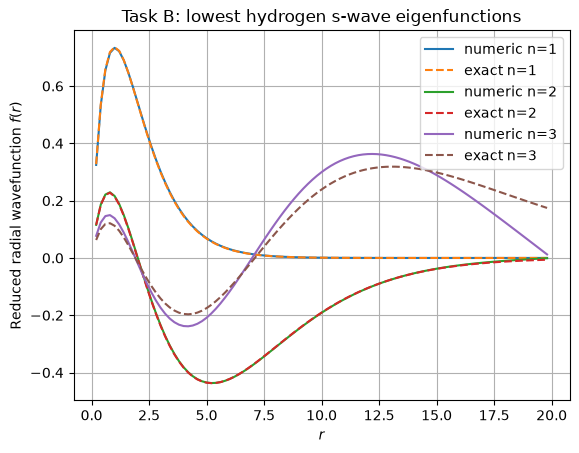

In [10]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("hydrogen_wavefunctions.data")

r = data[:, 0]

f0_num = data[:, 1]
f0_ex  = data[:, 2]

f1_num = data[:, 3]
f1_ex  = data[:, 4]

f2_num = data[:, 5]
f2_ex  = data[:, 6]

plt.figure()
plt.plot(r, f0_num, "-",  label="numeric n=1")
plt.plot(r, f0_ex,  "--", label="exact n=1")

plt.plot(r, f1_num, "-",  label="numeric n=2")
plt.plot(r, f1_ex,  "--", label="exact n=2")

plt.plot(r, f2_num, "-",  label="numeric n=3")
plt.plot(r, f2_ex,  "--", label="exact n=3")

plt.xlabel(r"$r$")
plt.ylabel(r"Reduced radial wavefunction $f(r)$")
plt.title(r"Task B: lowest hydrogen s-wave eigenfunctions")
plt.grid(True)
plt.legend()
plt.show()

### Task B conclusion

The radial Schrödinger equation for the hydrogen atom was represented on an equidistant grid and converted into a matrix eigenvalue problem,

$$
Hf = \epsilon f.
$$

The Hamiltonian matrix was built from the finite-difference approximation to the kinetic energy operator and the Coulomb potential $-1/r$. Diagonalizing this symmetric matrix with the Jacobi EVD routine gave numerical approximations to the bound-state energies and reduced radial wavefunctions.

For the ground state, the numerical energy converges toward the exact value

$$
E_0 = -0.5
$$

as the grid spacing $\Delta r$ is reduced. This shows that the finite-difference approximation improves when the grid becomes finer. The convergence study with fixed $\Delta r$ and varying $r_{\max}$ shows that increasing $r_{\max}$ improves the result only up to a point. After that, the remaining error is dominated mainly by the finite grid spacing.

The lowest numerical eigenfunctions agree well with the analytical hydrogen s-wave radial functions. The agreement is best for the first two states. The third state is less accurate, especially at larger $r$, because higher excited states are more spatially extended and therefore require a larger box size and/or a smaller grid spacing.

Overall, the calculation confirms that the Jacobi diagonalization routine works for the physical eigenvalue problem and that the finite-difference Hamiltonian gives the expected hydrogen spectrum in the limit of sufficiently small $\Delta r$ and sufficiently large $r_{\max}$.

## Task C

Scaling and optimization.

For this task, I choose the simplest option: check that the number of operations for matrix diagonalization scales as $O(n^3)$ by measuring the time for random symmetric matrices of size $n$. This matches the theory note that one Jacobi rotation costs $O(n)$, and a full sweep costs $O(n^3)$.

Task C1 — write time_evd.cpp:

In [11]:
from pathlib import Path

Path("time_evd.cpp").write_text(r'''
#include "evd.hpp"
#include <iostream>
#include <random>
#include <chrono>
#include <cstdlib>

pp::matrix random_symmetric_matrix(int n, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::matrix A(n, n);

    for (int i = 0; i < n; ++i) {
        for (int j = i; j < n; ++j) {
            double x = dist(gen);
            A(i, j) = x;
            A(j, i) = x;
        }
    }

    return A;
}

int main(int argc, char** argv) {
    int n = 50;

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-size" && i + 1 < argc) {
            n = std::atoi(argv[i + 1]);
            ++i;
        }
    }

    std::mt19937 gen(1);
    pp::matrix A = random_symmetric_matrix(n, gen);

    auto t1 = std::chrono::high_resolution_clock::now();

    pp::EVD evd(A, 1e-12, 300);

    auto t2 = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> dt = t2 - t1;

    std::cout << n << " "
              << dt.count() << " "
              << evd.sweeps << " "
              << evd.rotations << "\n";

    return 0;
}
''')

print("Wrote time_evd.cpp")

Wrote time_evd.cpp


Task C2 — compile time_evd.cpp:

In [12]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "time_evd.cpp",
    "-o",
    "time_evd"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    print("Compiled time_evd.cpp successfully.")
else:
    print("Compilation failed.")

Compiler output:


Compiled time_evd.cpp successfully.


Task C3 — generate timing data:

In [13]:
import subprocess
from pathlib import Path

Ns = list(range(10, 111, 10))

lines = []

for N in Ns:
    r = subprocess.run(
        ["./time_evd", "-size", str(N)],
        text=True,
        capture_output=True
    )

    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"time_evd failed for N={N}")

    line = r.stdout.strip()
    print(line)
    lines.append(line)

Path("out.evd_times.data").write_text("\n".join(lines) + "\n")

print("Wrote out.evd_times.data")

10 4.0868e-05 7 213
20 9.7181e-05 7 1021
30 0.000246423 8 2648
40 0.000673849 9 5115
50 0.00220278 9 7796
60 0.00215743 9 11608
70 0.00272246 9 15744
80 0.00387669 9 20879
90 0.00555112 9 26723
100 0.00833745 9 33231
110 0.0100932 9 40512
Wrote out.evd_times.data


Task C4 — plot timing and fit with $cN^3$:

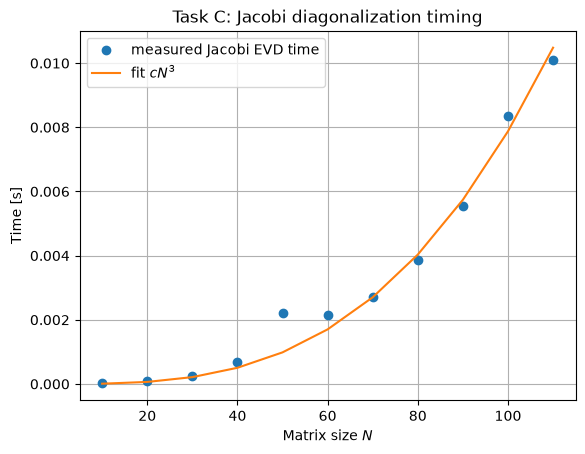

Fit constant c = 7.874e-09 s/N^3


In [14]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("out.evd_times.data")

N = data[:, 0]
t = data[:, 1]
sweeps = data[:, 2]
rotations = data[:, 3]

x = N**3
c = np.sum(x*t) / np.sum(x*x)
t_fit = c*x

plt.figure()
plt.plot(N, t, "o", label="measured Jacobi EVD time")
plt.plot(N, t_fit, "-", label=r"fit $cN^3$")
plt.xlabel("Matrix size $N$")
plt.ylabel("Time [s]")
plt.title("Task C: Jacobi diagonalization timing")
plt.grid(True)
plt.legend()
plt.show()

print(f"Fit constant c = {c:.3e} s/N^3")

Task C5 — optional log-log slope:

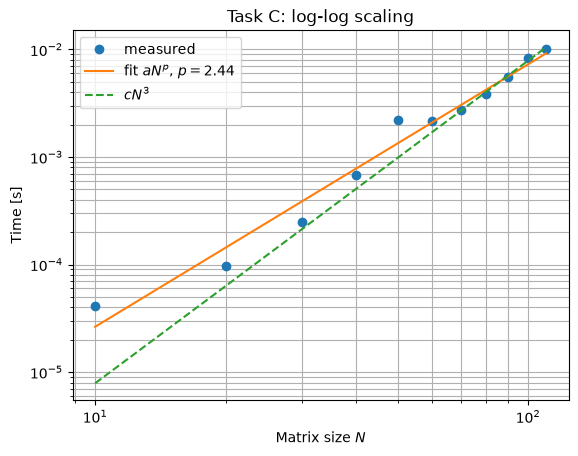

Fitted power p = 2.441


In [15]:
p, loga = np.polyfit(np.log(N), np.log(t), 1)
a = np.exp(loga)

plt.figure()
plt.loglog(N, t, "o", label="measured")
plt.loglog(N, a*N**p, "-", label=fr"fit $aN^p$, $p={p:.2f}$")
plt.loglog(N, c*N**3, "--", label=r"$cN^3$")
plt.xlabel("Matrix size $N$")
plt.ylabel("Time [s]")
plt.title("Task C: log-log scaling")
plt.grid(True, which="both")
plt.legend()
plt.show()

print(f"Fitted power p = {p:.3f}")

Trying to get it closer to $3$:

In [16]:
from pathlib import Path

Path("time_evd_better.cpp").write_text(r'''
#include "evd.hpp"
#include <iostream>
#include <random>
#include <chrono>
#include <cstdlib>
#include <string>

pp::matrix random_symmetric_matrix(int n, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::matrix A(n, n);

    for (int i = 0; i < n; ++i) {
        for (int j = i; j < n; ++j) {
            double x = dist(gen);
            A(i, j) = x;
            A(j, i) = x;
        }
    }

    return A;
}

int main(int argc, char** argv) {
    int n = 50;
    int repeats = 5;

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-size" && i + 1 < argc) {
            n = std::atoi(argv[i + 1]);
            ++i;
        }

        if (arg == "-repeats" && i + 1 < argc) {
            repeats = std::atoi(argv[i + 1]);
            ++i;
        }
    }

    std::mt19937 gen(1);
    pp::matrix A = random_symmetric_matrix(n, gen);

    int sweeps = 0;
    int rotations = 0;

    auto t1 = std::chrono::high_resolution_clock::now();

    for (int k = 0; k < repeats; ++k) {
        pp::EVD evd(A, 1e-12, 300);
        sweeps += evd.sweeps;
        rotations += evd.rotations;
    }

    auto t2 = std::chrono::high_resolution_clock::now();

    std::chrono::duration<double> dt = t2 - t1;

    double average_time = dt.count() / repeats;
    double average_sweeps = double(sweeps) / repeats;
    double average_rotations = double(rotations) / repeats;

    std::cout << n << " "
              << average_time << " "
              << average_sweeps << " "
              << average_rotations << " "
              << repeats << "\n";

    return 0;
}
''')

print("Wrote time_evd_better.cpp")

Wrote time_evd_better.cpp


In [17]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O3",
    "-Wall",
    "-Wextra",
    "time_evd_better.cpp",
    "-o",
    "time_evd_better"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    print("Compiled time_evd_better.cpp successfully.")
else:
    print("Compilation failed.")

Compiler output:


Compiled time_evd_better.cpp successfully.


In [18]:
import subprocess
from pathlib import Path

Ns = [20, 30, 40, 50, 60, 80, 100, 120, 140, 160, 180, 200]

lines = []

for N in Ns:
    # More repeats for small N, fewer for large N
    if N <= 50:
        repeats = 50
    elif N <= 100:
        repeats = 20
    elif N <= 150:
        repeats = 10
    else:
        repeats = 5

    r = subprocess.run(
        ["./time_evd_better", "-size", str(N), "-repeats", str(repeats)],
        text=True,
        capture_output=True
    )

    if r.returncode != 0:
        print(r.stderr)
        raise RuntimeError(f"time_evd_better failed for N={N}")

    line = r.stdout.strip()
    print(line)
    lines.append(line)

Path("out.evd_times_better.data").write_text("\n".join(lines) + "\n")

print("Wrote out.evd_times_better.data")

20 0.000153972 7 1021 50
30 0.000261785 8 2648 50
40 0.00057483 9 5115 50
50 0.000915467 9 7796 50
60 0.00147838 9 11608 20
80 0.00395615 9 20879 20
100 0.00730946 9 33231 20
120 0.0125556 10 50105 10
140 0.0182627 10 67584 10
160 0.0279057 10 89959 5
180 0.0381834 10 115016 5
200 0.0541836 10 142389 5
Wrote out.evd_times_better.data


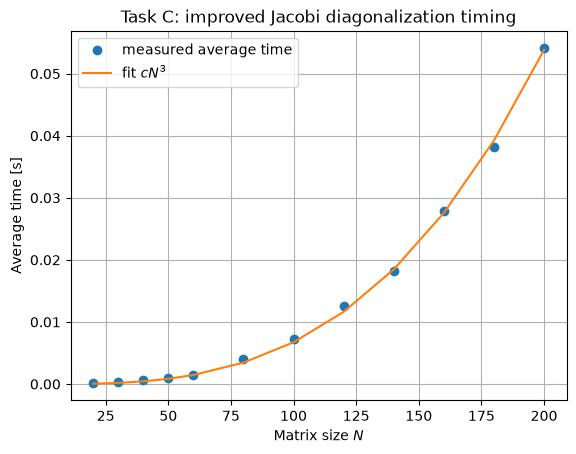

Fit constant c = 6.729e-09 s/N^3


In [19]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("out.evd_times_better.data")

N = data[:, 0]
t = data[:, 1]
sweeps = data[:, 2]
rotations = data[:, 3]
repeats = data[:, 4]

x = N**3
c = np.sum(x*t) / np.sum(x*x)
t_fit = c*x

plt.figure()
plt.plot(N, t, "o", label="measured average time")
plt.plot(N, t_fit, "-", label=r"fit $cN^3$")
plt.xlabel("Matrix size $N$")
plt.ylabel("Average time [s]")
plt.title("Task C: improved Jacobi diagonalization timing")
plt.grid(True)
plt.legend()
plt.show()

print(f"Fit constant c = {c:.3e} s/N^3")

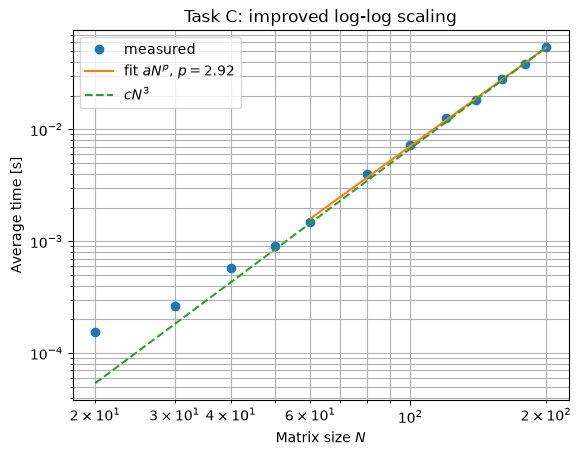

Fitted power using N >= 60: p = 2.924


In [20]:
mask = N >= 60

p, loga = np.polyfit(np.log(N[mask]), np.log(t[mask]), 1)
a = np.exp(loga)

plt.figure()
plt.loglog(N, t, "o", label="measured")
plt.loglog(N[mask], a*N[mask]**p, "-", label=fr"fit $aN^p$, $p={p:.2f}$")
plt.loglog(N, c*N**3, "--", label=r"$cN^3$")
plt.xlabel("Matrix size $N$")
plt.ylabel("Average time [s]")
plt.title("Task C: improved log-log scaling")
plt.grid(True, which="both")
plt.legend()
plt.show()

print(f"Fitted power using N >= 60: p = {p:.3f}")

### Task C conclusion

The timing experiment was improved by using larger matrix sizes and averaging over several repeated diagonalizations. This reduced the influence of timing noise and fixed overhead for small matrices.

The measured runtime follows the fitted $cN^3$ curve well, especially for the larger matrices. The log-log fit using $N \geq 60$ gave

$$
p \approx 2.92,
$$

which is close to the expected cubic scaling. This confirms that the Jacobi diagonalization routine scales approximately as

$$
O(N^3).
$$

The smallest matrix sizes deviate more from the cubic trend because the absolute runtimes are very small and overhead becomes relatively important. For the larger matrix sizes, the numerical measurements agree well with the theoretical operation count.